In [1]:
import geopandas as gpd

# Define the path to your GeoPackage file
file_path = r"C:\Users\rkhaz\Downloads\bag-light.gpkg"  # Replace with the actual file path

# Load the GeoPackage file
try:
    gdf = gpd.read_file(file_path)
    # Display the first few rows of the data
    print(gdf.head())
except Exception as e:
    print(f"Error reading the file: {e}")


c:\Users\rkhaz\anaconda3\envs\myenv\lib\site-packages\pyogrio\geopandas.py:265: UserWarning: More than one layer found in 'bag-light.gpkg': 'pand' (default), 'verblijfsobject', 'ligplaats', 'standplaats', 'woonplaats'. Specify layer parameter to avoid this warning.
  result = read_func(


                                         rdf_seealso     identificatie  \
0  http://bag.basisregistraties.overheid.nl/bag/i...  0010100000018750   
1  http://bag.basisregistraties.overheid.nl/bag/i...  0010100000018751   
2  http://bag.basisregistraties.overheid.nl/bag/i...  0010100000016899   
3  http://bag.basisregistraties.overheid.nl/bag/i...  0010100000016900   
4  http://bag.basisregistraties.overheid.nl/bag/i...  0010100000017819   

   bouwjaar           status gebruiksdoel  oppervlakte_min  oppervlakte_max  \
0      1972  Pand in gebruik         None              NaN              NaN   
1      1969  Pand in gebruik         None              NaN              NaN   
2      1946  Pand in gebruik  woonfunctie            712.0            712.0   
3      1973  Pand in gebruik  woonfunctie             89.0             89.0   
4      1930  Pand in gebruik         None              NaN              NaN   

   aantal_verblijfsobjecten                                           geometry  

In [2]:
huizen = gdf.copy()

In [3]:
shuffled = huizen.sample(frac=1, random_state=10).reset_index(drop=True)



In [4]:
# huisje = shuffled[['bouwjaar', 'geometry']]

huisje = shuffled[shuffled['gebruiksdoel'] == 'woonfunctie']

huisjes = huisje[huisje['status'] == 'Pand in gebruik']



In [14]:
huisjeeee = huisjes[600000:1200000][['bouwjaar', 'geometry']]

In [15]:
import pandas as pd
import geopandas as gpd
import numpy as np
from shapely.geometry import Point
from pyproj import Transformer

def convert_coordinates_vectorized(df):
    """Optimized coordinate conversion for large datasets"""


    # Convert to GeoDataFrame without deep copy
    gdf = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:28992")
    
    # Calculate centroids in a batch operation (this is fast)
    centroids = gdf.geometry.centroid

    # Extract x and y coordinates as numpy arrays for efficient transformation
    x = centroids.x.values
    y = centroids.y.values

    # Initialize the transformer once
    transformer = Transformer.from_crs("EPSG:28992", "EPSG:4326", always_xy=True)

    # Batch-transform the entire array of coordinates
    lng, lat = transformer.transform(x, y)

    # Store results back in a single assignment
    gdf['lat_lng'] = np.column_stack((lat, lng)).tolist()

    # Return only necessary columns to reduce memory use
    return gdf[['lat_lng', 'bouwjaar']].copy()

# Usage Example:
# df = pd.read_csv('large_file.csv')  # Ensure large file with columns 'x_coord', 'y_coord'
# optimized_result = convert_coordinates_vectorized(df)


In [16]:
test = convert_coordinates_vectorized(huisjeeee)

test.tail()

,lat_lng,bouwjaar
2496556,"[52.02086098451392, 5.057801407442293]",1969
2496557,"[52.25489444895011, 5.224739448730357]",1921
2496560,"[52.67691395359469, 5.965330715242442]",1980
2496562,"[52.62631002828529, 4.747239003363113]",1934
2496564,"[51.851216175094244, 4.538426000349782]",1973


1248815      [52.15170342576026, 4.65568530469346]
1248816     [52.25015717271369, 4.811573307251523]
1248818    [53.225343471190946, 6.584446406425371]
1248820    [52.272746690613985, 6.817598205779599]
1248821    [51.896042872132064, 4.153376078258686]
Name: lat_lng, dtype: object


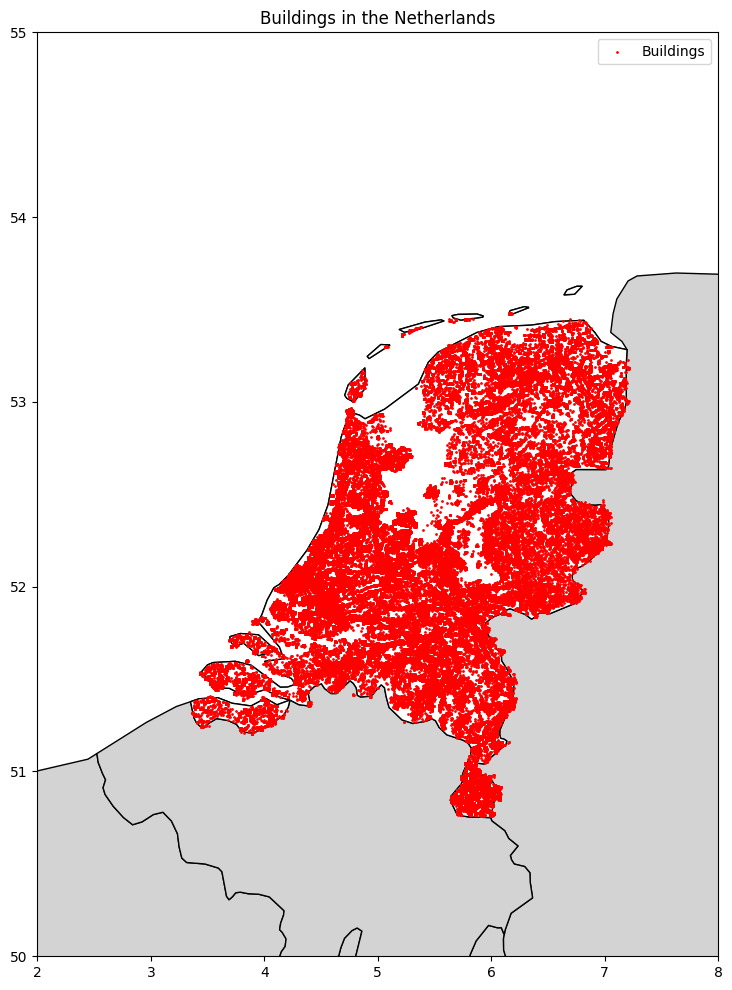

In [17]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

# File path to the downloaded shapefile
shapefile_path = r"C:\Users\rkhaz\Documents\Energy\countries\ne_50m_admin_0_countries.shp"

# Load the world shapefile and filter for the Netherlands
world = gpd.read_file(shapefile_path)
netherlands = world[world['ADMIN'] == 'Netherlands']  # Filter by country name

# Convert lat_lng to Point geometry
test['geometry'] = test['lat_lng'].apply(lambda x: Point(x[1], x[0]))  # lng first, lat second
gdf = gpd.GeoDataFrame(test, geometry='geometry', crs="EPSG:4326")

print(test['lat_lng'].head())  # Check if this contains valid lat/lng pairs


# Plot the map
fig, ax = plt.subplots(figsize=(14, 12))
world.plot(ax=ax, color='lightgray', edgecolor='black')
netherlands.plot(ax=ax, color='white', edgecolor='black')  # Plot only the Netherlands for clarity

# Plot the points
gdf.plot(ax=ax, color='red', markersize=1, label='Buildings')

plt.legend()
plt.title("Buildings in the Netherlands")

plt.xlim(2,8)
plt.ylim(50,55)
plt.show()


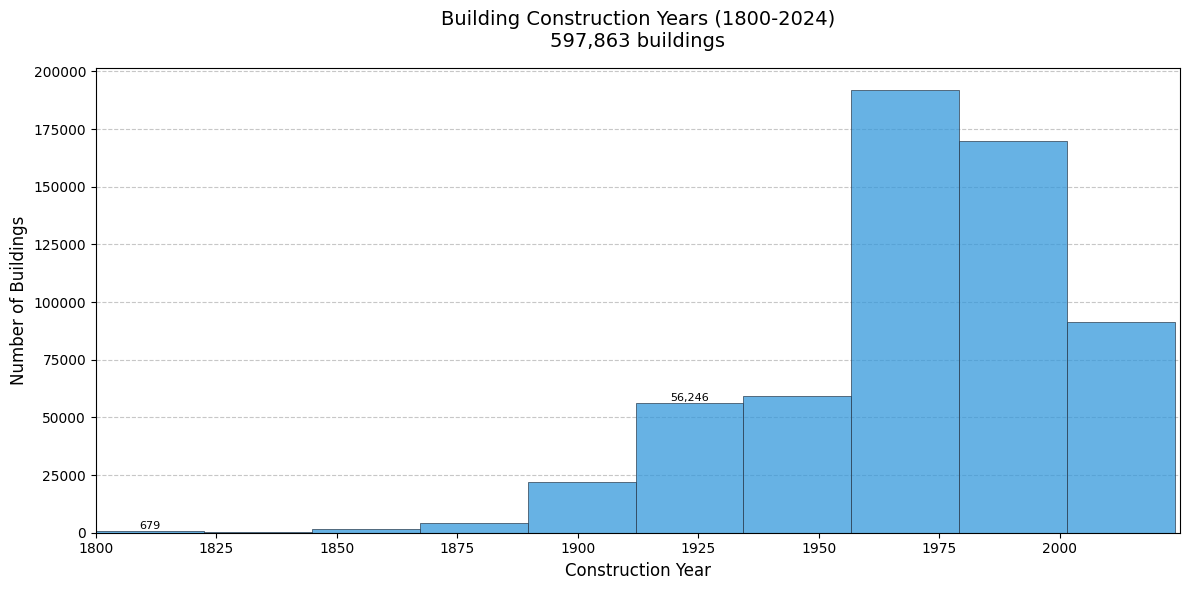

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_bouwjaar_histogram(df, bins=7, figsize=(12, 6)):
    """
    Plot a clean histogram of construction years between 1800-2024
    
    Parameters:
    df (pd.DataFrame): DataFrame with 'bouwjaar' column
    bins (int): Number of histogram bins
    """
    plt.figure(figsize=figsize)
    
    # Filter and clean data
    bouwjaar = df['bouwjaar'].dropna()
    bouwjaar = bouwjaar[(bouwjaar >= 1800) & (bouwjaar <= 2024)]  # Explicit filtering
    
    if len(bouwjaar) == 0:
        raise ValueError("No valid construction years between 1800-2024")
    
    # Create histogram with modern style
    ax = sns.histplot(bouwjaar, 
                     bins=bins,
                     color='#3498db',
                     edgecolor='#2c3e50',
                     linewidth=0.5,
                     kde=False)
    
    # Styling
    plt.title(f'Building Construction Years (1800-2024)\n{len(bouwjaar):,} buildings', 
             fontsize=14, pad=15)
    plt.xlabel('Construction Year', fontsize=12)
    plt.ylabel('Number of Buildings', fontsize=12)
    plt.xlim(1800, 2025)
    
    # Add grid and adjust ticks
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(range(1800, 2025, 25))  # Tick every 25 years
    plt.gca().set_axisbelow(True)  # Grid behind bars
    
    # Add value labels to every 5th bar
    for i, bar in enumerate(ax.patches):
        if i % 5 == 0:  # Label every 5th bar to avoid clutter
            height = bar.get_height()
            if height > 0:
                ax.text(bar.get_x() + bar.get_width()/2., height,
                        f'{int(height):,}',
                        ha='center', va='bottom',
                        fontsize=8)
    
    plt.tight_layout()
    plt.show()

# Usage
plot_bouwjaar_histogram(test, bins=10)

In [25]:
test

,lat_lng,bouwjaar,geometry
1248815,"[52.15170342576026, 4.65568530469346]",1986,POINT (4.65568530469346 52.15170342576026)
1248816,"[52.25015717271369, 4.811573307251523]",2015,POINT (4.811573307251523 52.25015717271369)
1248818,"[53.225343471190946, 6.584446406425371]",1932,POINT (6.584446406425371 53.225343471190946)
1248820,"[52.272746690613985, 6.817598205779599]",1956,POINT (6.817598205779599 52.272746690613985)
1248821,"[51.896042872132064, 4.153376078258686]",2009,POINT (4.153376078258686 51.896042872132064)
...,...,...,...
2496556,"[52.02086098451392, 5.057801407442293]",1969,POINT (5.057801407442293 52.02086098451392)
2496557,"[52.25489444895011, 5.224739448730357]",1921,POINT (5.224739448730357 52.25489444895011)
2496560,"[52.67691395359469, 5.965330715242442]",1980,POINT (5.965330715242442 52.67691395359469)
2496562,"[52.62631002828529, 4.747239003363113]",1934,POINT (4.747239003363113 52.62631002828529)


In [14]:
import loader
from concurrent.futures import ThreadPoolExecutor, as_completed

tester = test[test['bouwjaar'] > 1899][:30]

import pickle

tester.to_pickle('C:\Users\rkhaz\Documents\Drive\database_1.pkl')

# Function to retrieve and update data for a single row
def process_row(idx, row):
    image_path, distance = loader.retrieve_image(row['lat_lng'], idx, max_distance= 10)
    return idx, image_path, distance

# Initialize counter and DataFrame columnks
valid_count = 0
tester["distance"] = None
tester["image_path"] = None

# Define the maximum number of threads (adjust based on your system)
max_threads = 20

# Use ThreadPoolExecutor to process rows in parallel
with ThreadPoolExecutor(max_threads) as executor:
    # Submit tasks
    future_to_idx = {executor.submit(process_row, idx, row): idx for idx, row in tester.iterrows()}
    
    for future in as_completed(future_to_idx):
        idx = future_to_idx[future]
        
        try:
            # Get the result from the completed task
            idx, image_path, distance = future.result()
            
            # Update DataFrame with retrieved data
            tester.at[idx, 'distance'] = distance
            tester.at[idx, 'image_path'] = image_path
            
            # Update the valid count if image path is not None
            if image_path is not None:
                valid_count += 1
                print(valid_count)

            # Check the break condition
            if valid_count > 24500:
                print(f'Done at row {idx}')
                break

        except Exception as e:
            print(f"Error processing row {idx}: {e}")


In [17]:
df = tester.copy()

In [22]:
# Add a new column for the file paths
df['image_path'] = df.index.map(lambda idx: f"images_houses/{idx}.jpg")

# Display the DataFrame to check the result
df.head()

,lat_lng,bouwjaar,image_path
0,"[51.85926607220966, 6.05709712232219]",1983,images_houses/0.jpg
3,"[51.921586267093126, 4.5172498316210765]",1909,images_houses/3.jpg
4,"[52.2928761678912, 4.672307882914932]",1996,images_houses/4.jpg
7,"[51.63965498202956, 4.865569138898435]",1928,images_houses/7.jpg
8,"[52.35338110391445, 6.855062149816465]",1972,images_houses/8.jpg


In [155]:
import os

# Define the folder where the images are stored
image_folder = r"C:\Users\rkhaz\Documents\Drive\ml_fun\images_houses"

# Add a new column to indicate whether the file exists (1 if it exists, 0 if not)
df['file_exists'] = df.index.map(
    lambda idx: 1 if os.path.exists(os.path.join(image_folder, f"{idx}.jpg")) else 0
)

In [27]:
import os

# Define the base folder where the images are stored
image_folder = r"C:\Users\rkhaz\Documents\Drive\ml_fun"

# Check file existence using the full path from image_folder and image_path
df['file_exists'] = df['image_path'].map(
    lambda path: 1 if os.path.exists(f"{image_folder}/{path}") else 0
)



In [29]:
df = df[df['file_exists'] == 1]

In [22]:
df.to_pickle(r'database.pkl')